In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "report" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LR_PREDICTIONS_PATH = RESULTS_DIR / "logistic_regression_predictions.csv"
LR_RESULTS_PATH = RESULTS_DIR / "logistic_regression_results.csv"

ERROR_ANALYSIS_PATH = RESULTS_DIR / "error_analysis.csv"
ERROR_ANALYSIS_SUMMARY_PATH = RESULTS_DIR / "error_analysis_summary.csv"

print("Project root:", PROJECT_ROOT)
print("LR predictions path:", LR_PREDICTIONS_PATH)
print("Error analysis output path:", ERROR_ANALYSIS_PATH)

Project root: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project
LR predictions path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\logistic_regression_predictions.csv
Error analysis output path: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\error_analysis.csv


In [3]:
prediction_df = pd.read_csv(LR_PREDICTIONS_PATH, encoding="utf-8-sig")

print("Prediction dataframe shape:", prediction_df.shape)
prediction_df.head()

Prediction dataframe shape: (494, 10)


,comment,clean_comment,chat_luong,dong_goi,van_chuyen,gia_ca,pred_chat_luong,pred_dong_goi,pred_van_chuyen,pred_gia_ca
0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,negative,neutral,positive,positive,positive,neutral,positive,positive
1,nan ô mỏng bằng sợi tóc. ô nhỏ chán,nan ô mỏng bằng sợi tóc ô nhỏ chán,negative,neutral,neutral,neutral,negative,neutral,neutral,neutral
2,giao nhanh date mới date xa,giao nhanh date mới date xa,positive,neutral,positive,neutral,positive,neutral,positive,neutral
3,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,negative,negative,neutral,neutral,negative,negative,neutral,neutral
4,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...,neutral,neutral,neutral,neutral,neutral,neutral,neutral,negative


In [4]:
prediction_df.columns.tolist()

['comment',
 'clean_comment',
 'chat_luong',
 'dong_goi',
 'van_chuyen',
 'gia_ca',
 'pred_chat_luong',
 'pred_dong_goi',
 'pred_van_chuyen',
 'pred_gia_ca']

In [5]:
aspect_columns = [
    "chat_luong",
    "dong_goi",
    "van_chuyen",
    "gia_ca"
]

label_order = ["positive", "negative", "neutral"]

In [6]:
error_counts = []

for aspect in aspect_columns:
    true_col = aspect
    pred_col = f"pred_{aspect}"

    total_samples = len(prediction_df)
    wrong_count = (prediction_df[true_col] != prediction_df[pred_col]).sum()
    correct_count = total_samples - wrong_count
    error_rate = wrong_count / total_samples

    error_counts.append({
        "aspect": aspect,
        "total_samples": total_samples,
        "correct_count": correct_count,
        "wrong_count": wrong_count,
        "error_rate": error_rate
    })

error_counts_df = pd.DataFrame(error_counts)
error_counts_df["error_rate"] = error_counts_df["error_rate"].round(4)

error_counts_df

,aspect,total_samples,correct_count,wrong_count,error_rate
0,chat_luong,494,431,63,0.1275
1,dong_goi,494,437,57,0.1154
2,van_chuyen,494,473,21,0.0425
3,gia_ca,494,472,22,0.0445


In [7]:
error_rows = []

for idx, row in prediction_df.iterrows():
    for aspect in aspect_columns:
        true_label = row[aspect]
        predicted_label = row[f"pred_{aspect}"]

        if true_label != predicted_label:
            error_rows.append({
                "row_id": idx,
                "comment": row["comment"],
                "clean_comment": row["clean_comment"],
                "aspect": aspect,
                "true_label": true_label,
                "predicted_label": predicted_label
            })

errors_df = pd.DataFrame(error_rows)

print("Number of wrong aspect-level predictions:", len(errors_df))
errors_df.head(10)

Number of wrong aspect-level predictions: 163


,row_id,comment,clean_comment,aspect,true_label,predicted_label
0,0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,chat_luong,negative,positive
1,4,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...,gia_ca,neutral,negative
2,17,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,dong_goi,negative,neutral
3,20,hàng đẹp vải tốt mới nhận chưa dùng thử,hàng đẹp vải tốt mới nhận chưa dùng thử,chat_luong,positive,neutral
4,22,chất lượng tốt đúng mô tả không có sạc nhanh,chất lượng tốt đúng mô tả không có sạc nhanh,chat_luong,neutral,positive
5,29,bút dùng tốt không vấn đề gì,bút dùng tốt không vấn đề gì,chat_luong,positive,negative
6,30,vali gọn bắt mắt khung gập không ổn lỏng lẻo x...,vali gọn bắt mắt khung gập không ổn lỏng lẻo x...,dong_goi,negative,neutral
7,37,gửi hàng kẹp 2 miếng bìa cường lực bể vỡ. nhắn...,gửi hàng kẹp 2 miếng bìa cường lực bể vỡ nhắn ...,dong_goi,negative,neutral
8,39,vali không kín giá cao hơn bán ở chợ,vali không kín giá cao hơn bán ở chợ,chat_luong,negative,neutral
9,40,đổi bao bì mới đóng gói cẩn thận bé tăng cân,đổi bao bì mới đóng gói cẩn thận bé tăng cân,chat_luong,negative,positive


In [8]:
errors_by_aspect = (
    errors_df["aspect"]
    .value_counts()
    .reset_index()
)

errors_by_aspect.columns = ["aspect", "num_errors"]

errors_by_aspect

,aspect,num_errors
0,chat_luong,63
1,dong_goi,57
2,gia_ca,22
3,van_chuyen,21


In [9]:
error_type_summary = (
    errors_df
    .groupby(["aspect", "true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["aspect", "count"], ascending=[True, False])
)

error_type_summary

,aspect,true_label,predicted_label,count
1,chat_luong,negative,positive,21
4,chat_luong,positive,negative,16
0,chat_luong,negative,neutral,13
3,chat_luong,neutral,positive,5
2,chat_luong,neutral,negative,4
5,chat_luong,positive,neutral,4
8,dong_goi,neutral,negative,19
6,dong_goi,negative,neutral,17
11,dong_goi,positive,neutral,11
9,dong_goi,neutral,positive,4


In [10]:
error_type_summary = (
    errors_df
    .groupby(["aspect", "true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["aspect", "count"], ascending=[True, False])
)

error_type_summary

,aspect,true_label,predicted_label,count
1,chat_luong,negative,positive,21
4,chat_luong,positive,negative,16
0,chat_luong,negative,neutral,13
3,chat_luong,neutral,positive,5
2,chat_luong,neutral,negative,4
5,chat_luong,positive,neutral,4
8,dong_goi,neutral,negative,19
6,dong_goi,negative,neutral,17
11,dong_goi,positive,neutral,11
9,dong_goi,neutral,positive,4


In [11]:
sampled_error_examples = []

N_EXAMPLES_PER_ASPECT = 10

for aspect in aspect_columns:
    aspect_errors = errors_df[errors_df["aspect"] == aspect].copy()

    if len(aspect_errors) == 0:
        continue

    sampled = aspect_errors.sample(
        n=min(N_EXAMPLES_PER_ASPECT, len(aspect_errors)),
        random_state=42
    )

    sampled_error_examples.append(sampled)

sampled_error_examples_df = pd.concat(
    sampled_error_examples,
    ignore_index=True
)

sampled_error_examples_df

,row_id,comment,clean_comment,aspect,true_label,predicted_label
0,480,túi cũng được. giao hàng nhanh,túi cũng được giao hàng nhanh,chat_luong,positive,neutral
1,441,mua 2 thùng giá rẻ,mua 2 thùng giá rẻ,chat_luong,negative,positive
2,0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,chat_luong,negative,positive
3,292,vải mềm mịn mới nhận chưa sử dụng,vải mềm mịn mới nhận chưa sử dụng,chat_luong,positive,neutral
4,40,đổi bao bì mới đóng gói cẩn thận bé tăng cân,đổi bao bì mới đóng gói cẩn thận bé tăng cân,chat_luong,negative,positive
5,240,sữa ít đường dễ uống bé hợp tác chưa thấy tăng...,sữa ít đường dễ uống bé hợp tác chưa thấy tăng...,chat_luong,negative,positive
6,97,không đẹp tạm chấp nhận,không đẹp tạm chấp nhận,chat_luong,positive,negative
7,67,tập lớn bìa dày viết thoải mái. giấy mỏng dễ l...,tập lớn bìa dày viết thoải mái giấy mỏng dễ le...,chat_luong,negative,positive
8,171,giao hàng nhanh shipper thân thiện. không phù ...,giao hàng nhanh người giao hàng thân thiện khô...,chat_luong,negative,positive
9,473,Giao trễ,giao trễ,chat_luong,neutral,negative


In [12]:
sampled_error_examples_df["possible_reason"] = ""

sampled_error_examples_df.head()

,row_id,comment,clean_comment,aspect,true_label,predicted_label,possible_reason
0,480,túi cũng được. giao hàng nhanh,túi cũng được giao hàng nhanh,chat_luong,positive,neutral,
1,441,mua 2 thùng giá rẻ,mua 2 thùng giá rẻ,chat_luong,negative,positive,
2,0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,chat_luong,negative,positive,
3,292,vải mềm mịn mới nhận chưa sử dụng,vải mềm mịn mới nhận chưa sử dụng,chat_luong,positive,neutral,
4,40,đổi bao bì mới đóng gói cẩn thận bé tăng cân,đổi bao bì mới đóng gói cẩn thận bé tăng cân,chat_luong,negative,positive,


In [13]:
def suggest_error_reason(comment, clean_comment, aspect, true_label, predicted_label):
    """
    Suggest a possible reason for a wrong prediction.
    This is heuristic-based and should be manually reviewed.
    """

    text = str(clean_comment).lower()
    original = str(comment).lower()

    tokens = text.split()
    num_tokens = len(tokens)

    receive_xu_keywords = [
        "nhận xu", "nhan xu", "lấy xu", "lay xu",
        "xu", "đánh giá lấy xu", "hình ảnh mang tính chất"
    ]

    teencode_or_typo_keywords = [
        "ko", "khum", "hok", "hong", "k ", "sp", "shoppp",
        "okkk", "đẹpp", "nhanhhh"
    ]

    sarcasm_keywords = [
        "quá trời", "cạn lời", "chịu", "hết nói",
        "khỏi nói", "đỉnh thật", "hay quá"
    ]

    aspect_keywords = {
        "chat_luong": [
            "chất lượng", "sản phẩm", "vải", "mỏng", "dày",
            "đẹp", "xấu", "lỗi", "hỏng", "tốt", "kém"
        ],
        "dong_goi": [
            "đóng gói", "gói", "bao bì", "móp", "méo",
            "rách", "vỡ", "thiếu", "sai hàng"
        ],
        "van_chuyen": [
            "giao", "giao hàng", "ship", "shipper",
            "nhanh", "chậm", "lâu", "vận chuyển"
        ],
        "gia_ca": [
            "giá", "rẻ", "đắt", "tiền", "đáng tiền",
            "không đáng", "voucher", "sale", "khuyến mãi"
        ]
    }

    positive_neutral_confusion = (
        {true_label, predicted_label} == {"positive", "neutral"}
    )

    negative_minority_confusion = (
        true_label == "negative" and predicted_label != "negative"
    )

    # 1. Very short comment
    if num_tokens <= 3:
        return "Comment quá ngắn"

    # 6. Review-for-reward content
    if any(keyword in original or keyword in text for keyword in receive_xu_keywords):
        return "Comment nhận xu, không có thông tin thật"

    # 7. Aspect not clearly mentioned
    keywords = aspect_keywords.get(aspect, [])
    if not any(keyword in text for keyword in keywords):
        return "Aspect không được nhắc đến rõ ràng"

    # 4. Ambiguous between positive and neutral
    if positive_neutral_confusion:
        return "Comment mơ hồ giữa positive và neutral"

    # 8. Negative class may be underrepresented
    if negative_minority_confusion:
        return "Negative class quá ít nên model học chưa tốt"

    # 3. Typo / teencode
    if any(keyword in original for keyword in teencode_or_typo_keywords):
        return "Comment có lỗi chính tả hoặc teencode"

    # 5. Sarcasm / unclear context
    if any(keyword in text for keyword in sarcasm_keywords):
        return "Comment mỉa mai hoặc không rõ ngữ cảnh"

    # 2. Multiple aspects in one sentence
    aspect_mention_count = 0
    for aspect_name, keywords_list in aspect_keywords.items():
        if any(keyword in text for keyword in keywords_list):
            aspect_mention_count += 1

    if aspect_mention_count >= 2:
        return "Comment có nhiều aspect trong một câu"

    return "Khác"

In [14]:
sampled_error_examples_df["possible_reason"] = sampled_error_examples_df.apply(
    lambda row: suggest_error_reason(
        comment=row["comment"],
        clean_comment=row["clean_comment"],
        aspect=row["aspect"],
        true_label=row["true_label"],
        predicted_label=row["predicted_label"]
    ),
    axis=1
)

sampled_error_examples_df.head(20)

,row_id,comment,clean_comment,aspect,true_label,predicted_label,possible_reason
0,480,túi cũng được. giao hàng nhanh,túi cũng được giao hàng nhanh,chat_luong,positive,neutral,Aspect không được nhắc đến rõ ràng
1,441,mua 2 thùng giá rẻ,mua 2 thùng giá rẻ,chat_luong,negative,positive,Aspect không được nhắc đến rõ ràng
2,0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,chat_luong,negative,positive,Negative class quá ít nên model học chưa tốt
3,292,vải mềm mịn mới nhận chưa sử dụng,vải mềm mịn mới nhận chưa sử dụng,chat_luong,positive,neutral,Comment mơ hồ giữa positive và neutral
4,40,đổi bao bì mới đóng gói cẩn thận bé tăng cân,đổi bao bì mới đóng gói cẩn thận bé tăng cân,chat_luong,negative,positive,Aspect không được nhắc đến rõ ràng
5,240,sữa ít đường dễ uống bé hợp tác chưa thấy tăng...,sữa ít đường dễ uống bé hợp tác chưa thấy tăng...,chat_luong,negative,positive,Aspect không được nhắc đến rõ ràng
6,97,không đẹp tạm chấp nhận,không đẹp tạm chấp nhận,chat_luong,positive,negative,Khác
7,67,tập lớn bìa dày viết thoải mái. giấy mỏng dễ l...,tập lớn bìa dày viết thoải mái giấy mỏng dễ le...,chat_luong,negative,positive,Negative class quá ít nên model học chưa tốt
8,171,giao hàng nhanh shipper thân thiện. không phù ...,giao hàng nhanh người giao hàng thân thiện khô...,chat_luong,negative,positive,Aspect không được nhắc đến rõ ràng
9,473,Giao trễ,giao trễ,chat_luong,neutral,negative,Comment quá ngắn


In [15]:
sampled_error_examples_df.to_csv(
    ERROR_ANALYSIS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved error analysis to:", ERROR_ANALYSIS_PATH)

Saved error analysis to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\error_analysis.csv


In [16]:
all_errors_with_reason = errors_df.copy()

all_errors_with_reason["possible_reason"] = all_errors_with_reason.apply(
    lambda row: suggest_error_reason(
        comment=row["comment"],
        clean_comment=row["clean_comment"],
        aspect=row["aspect"],
        true_label=row["true_label"],
        predicted_label=row["predicted_label"]
    ),
    axis=1
)

all_errors_with_reason.head()

,row_id,comment,clean_comment,aspect,true_label,predicted_label,possible_reason
0,0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,chat_luong,negative,positive,Negative class quá ít nên model học chưa tốt
1,4,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...,gia_ca,neutral,negative,Aspect không được nhắc đến rõ ràng
2,17,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,dong_goi,negative,neutral,Aspect không được nhắc đến rõ ràng
3,20,hàng đẹp vải tốt mới nhận chưa dùng thử,hàng đẹp vải tốt mới nhận chưa dùng thử,chat_luong,positive,neutral,Comment mơ hồ giữa positive và neutral
4,22,chất lượng tốt đúng mô tả không có sạc nhanh,chất lượng tốt đúng mô tả không có sạc nhanh,chat_luong,neutral,positive,Comment mơ hồ giữa positive và neutral


In [17]:
ALL_ERROR_ANALYSIS_PATH = RESULTS_DIR / "error_analysis_all_wrong_predictions.csv"

all_errors_with_reason.to_csv(
    ALL_ERROR_ANALYSIS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved all wrong predictions to:", ALL_ERROR_ANALYSIS_PATH)

Saved all wrong predictions to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\error_analysis_all_wrong_predictions.csv


In [18]:
error_reason_summary = (
    all_errors_with_reason
    .groupby("possible_reason")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_reason_summary["percentage"] = (
    error_reason_summary["count"] / error_reason_summary["count"].sum() * 100
).round(2)

error_reason_summary

,possible_reason,count,percentage
0,Aspect không được nhắc đến rõ ràng,84,51.53
6,Negative class quá ít nên model học chưa tốt,23,14.11
3,Comment mơ hồ giữa positive và neutral,20,12.27
5,Khác,13,7.98
2,Comment có nhiều aspect trong một câu,11,6.75
4,Comment quá ngắn,11,6.75
1,Comment có lỗi chính tả hoặc teencode,1,0.61


In [19]:
error_reason_summary.to_csv(
    ERROR_ANALYSIS_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved error analysis summary to:", ERROR_ANALYSIS_SUMMARY_PATH)

Saved error analysis summary to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\error_analysis_summary.csv


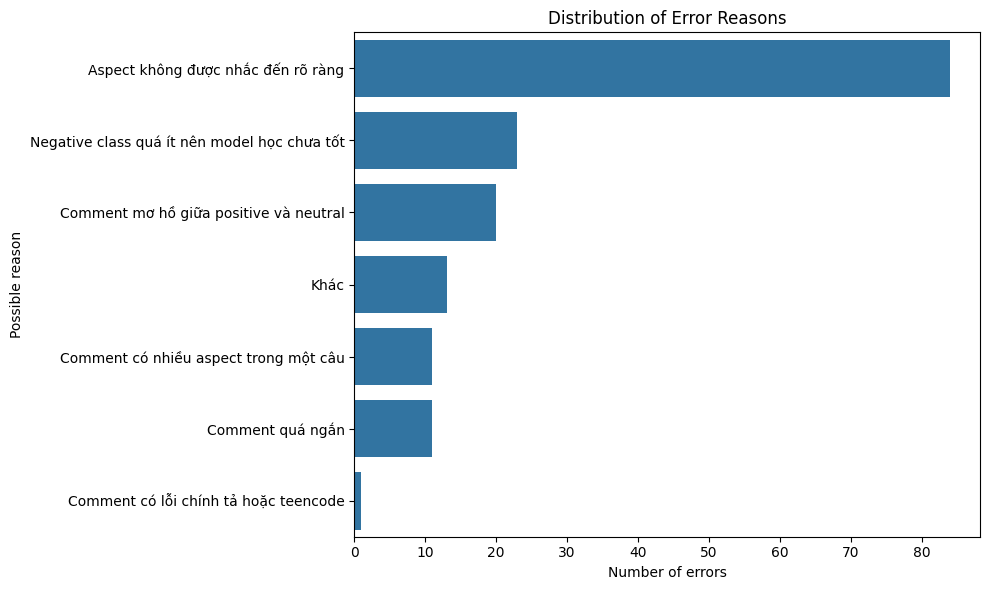

Saved figure to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\report\figures\error_reason_distribution.png


In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=error_reason_summary,
    x="count",
    y="possible_reason"
)

plt.title("Distribution of Error Reasons")
plt.xlabel("Number of errors")
plt.ylabel("Possible reason")
plt.tight_layout()

ERROR_REASON_FIGURE_PATH = FIGURES_DIR / "error_reason_distribution.png"

plt.savefig(ERROR_REASON_FIGURE_PATH, dpi=300)
plt.show()

print("Saved figure to:", ERROR_REASON_FIGURE_PATH)

In [21]:
error_reason_by_aspect = (
    all_errors_with_reason
    .groupby(["aspect", "possible_reason"])
    .size()
    .reset_index(name="count")
    .sort_values(["aspect", "count"], ascending=[True, False])
)

error_reason_by_aspect

,aspect,possible_reason,count
0,chat_luong,Aspect không được nhắc đến rõ ràng,32
5,chat_luong,Negative class quá ít nên model học chưa tốt,13
2,chat_luong,Comment mơ hồ giữa positive và neutral,7
4,chat_luong,Khác,5
1,chat_luong,Comment có nhiều aspect trong một câu,3
3,chat_luong,Comment quá ngắn,3
6,dong_goi,Aspect không được nhắc đến rõ ràng,42
11,dong_goi,Negative class quá ít nên model học chưa tốt,5
9,dong_goi,Comment quá ngắn,4
7,dong_goi,Comment có nhiều aspect trong một câu,2


In [22]:
ERROR_REASON_BY_ASPECT_PATH = RESULTS_DIR / "error_reason_by_aspect.csv"

error_reason_by_aspect.to_csv(
    ERROR_REASON_BY_ASPECT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved error reason by aspect to:", ERROR_REASON_BY_ASPECT_PATH)

Saved error reason by aspect to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\error_reason_by_aspect.csv


In [23]:
for aspect in aspect_columns:
    print(f"\nAspect: {aspect}")

    display(
        all_errors_with_reason[
            all_errors_with_reason["aspect"] == aspect
        ][
            [
                "comment",
                "clean_comment",
                "true_label",
                "predicted_label",
                "possible_reason"
            ]
        ].head(10)
    )


Aspect: chat_luong


,comment,clean_comment,true_label,predicted_label,possible_reason
0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,negative,positive,Negative class quá ít nên model học chưa tốt
3,hàng đẹp vải tốt mới nhận chưa dùng thử,hàng đẹp vải tốt mới nhận chưa dùng thử,positive,neutral,Comment mơ hồ giữa positive và neutral
4,chất lượng tốt đúng mô tả không có sạc nhanh,chất lượng tốt đúng mô tả không có sạc nhanh,neutral,positive,Comment mơ hồ giữa positive và neutral
5,bút dùng tốt không vấn đề gì,bút dùng tốt không vấn đề gì,positive,negative,Khác
8,vali không kín giá cao hơn bán ở chợ,vali không kín giá cao hơn bán ở chợ,negative,neutral,Aspect không được nhắc đến rõ ràng
9,đổi bao bì mới đóng gói cẩn thận bé tăng cân,đổi bao bì mới đóng gói cẩn thận bé tăng cân,negative,positive,Aspect không được nhắc đến rõ ràng
12,giao hàng không sạc pin sẵn,giao hàng không sạc pin sẵn,negative,neutral,Aspect không được nhắc đến rõ ràng
15,đóng gói cẩn thận kĩ càng. giao hàng nhanh chó...,đóng gói cẩn thận kĩ càng giao hàng nhanh chón...,negative,positive,Aspect không được nhắc đến rõ ràng
20,mau hư hơn loại khác dùng 3 ngày sứt chỉ ngày ...,mau hư hơn loại khác dùng 3 ngày sứt chỉ ngày ...,negative,positive,Negative class quá ít nên model học chưa tốt
22,ghi 24 xương nhưng hóa ra loại 8 xương giá rẻ ...,ghi 24 xương nhưng hóa ra loại 8 xương giá rẻ ...,positive,negative,Aspect không được nhắc đến rõ ràng



Aspect: dong_goi


,comment,clean_comment,true_label,predicted_label,possible_reason
2,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,negative,neutral,Aspect không được nhắc đến rõ ràng
6,vali gọn bắt mắt khung gập không ổn lỏng lẻo x...,vali gọn bắt mắt khung gập không ổn lỏng lẻo x...,negative,neutral,Aspect không được nhắc đến rõ ràng
7,gửi hàng kẹp 2 miếng bìa cường lực bể vỡ. nhắn...,gửi hàng kẹp 2 miếng bìa cường lực bể vỡ nhắn ...,negative,neutral,Negative class quá ít nên model học chưa tốt
10,vợt bình thường vì giá rẻ nhưng cầu là cầu nhựa,vợt bình thường vì giá rẻ nhưng cầu là cầu nhựa,neutral,negative,Aspect không được nhắc đến rõ ràng
14,hương vị thơm ngon dễ uống hộp chắc chắn tiện ...,hương vị thơm ngon dễ uống hộp chắc chắn tiện ...,positive,neutral,Aspect không được nhắc đến rõ ràng
16,giao hàng nhanh đầy đủ có tặng thêm. ngòi hơi bẩn,giao hàng nhanh đầy đủ có tặng thêm ngòi hơi bẩn,positive,negative,Aspect không được nhắc đến rõ ràng
18,mở ra miếng dán đã vỡ tan mặc dù bọc không ít xốp,mở ra miếng dán đã vỡ tan mặc dù bọc không ít xốp,positive,negative,Khác
19,không đúng mô tả viền camera to trông thô kinh,không đúng mô tả viền camera to trông thô kinh,neutral,negative,Aspect không được nhắc đến rõ ràng
28,tập lớn bìa dày viết thoải mái. giấy mỏng dễ l...,tập lớn bìa dày viết thoải mái giấy mỏng dễ le...,positive,neutral,Aspect không được nhắc đến rõ ràng
36,bé chịu uống vị ngọt vừa không quá gắt,bé chịu uống vị ngọt vừa không quá gắt,negative,neutral,Aspect không được nhắc đến rõ ràng



Aspect: van_chuyen


,comment,clean_comment,true_label,predicted_label,possible_reason
13,giao hàng không sạc pin sẵn,giao hàng không sạc pin sẵn,neutral,negative,Khác
21,mau hư hơn loại khác dùng 3 ngày sứt chỉ ngày ...,mau hư hơn loại khác dùng 3 ngày sứt chỉ ngày ...,positive,negative,Comment có nhiều aspect trong một câu
31,vải lông thấm hút xọc xạch phải chịu khó để ý ...,vải lông thấm hút xọc xạch phải chịu khó để ý ...,positive,neutral,Comment mơ hồ giữa positive và neutral
39,giao hàng cũ bị trầy xước nhiều,giao hàng cũ bị trầy xước nhiều,neutral,negative,Khác
46,shop đóng hàng nhanh kỹ sữa thơm ngon ít ngọt,shop đóng hàng nhanh kỹ sữa thơm ngon ít ngọt,neutral,positive,Comment mơ hồ giữa positive và neutral
57,giao cường lực bị bể vỡ từ trước chứ không phả...,giao cường lực bị bể vỡ từ trước chứ không phả...,neutral,negative,Comment có nhiều aspect trong một câu
59,hàng xịn xò cứng cáp chắc chắn remote chụp hìn...,hàng xịn xò cứng cáp chắc chắn remote chụp hìn...,positive,neutral,Comment mơ hồ giữa positive và neutral
65,giao hàng cũ,giao hàng cũ,neutral,negative,Comment quá ngắn
74,giao thiếu hàng đặt 2 ốp 3 cường lực giao 1 bộ,giao thiếu hàng đặt 2 ốp 3 cường lực giao 1 bộ,neutral,negative,Comment có nhiều aspect trong một câu
91,hàng xài tạm giao hàng cũ khóa bên ăn bên không,hàng xài tạm giao hàng cũ khóa bên ăn bên không,neutral,negative,Khác



Aspect: gia_ca


,comment,clean_comment,true_label,predicted_label,possible_reason
1,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...,neutral,negative,Aspect không được nhắc đến rõ ràng
11,giá rẻ nhưng mút cứng,giá rẻ nhưng mút cứng,positive,negative,Khác
17,có 4g 1 tháng hết 4g không đọc báo được luôn. ...,có 4g 1 tháng hết 4g không đọc báo được luôn m...,negative,neutral,Aspect không được nhắc đến rõ ràng
24,sữa thơm béo ít ngọt bao bì chắc chắn giá vừa ...,sữa thơm béo ít ngọt bao bì chắc chắn giá vừa ...,positive,neutral,Comment mơ hồ giữa positive và neutral
26,"Không có đâu :))), Shop gian lận lượt đánh giá",không có đâu shop gian lận lượt đánh giá,neutral,negative,Khác
32,sản phẩm rẻ đẹp dùng tiện. kê điện thoại chắc ...,sản phẩm rẻ đẹp dùng tiện kê điện thoại chắc chắn,positive,neutral,Comment mơ hồ giữa positive và neutral
33,quá tệ chất lượng không xứng tiền hình in bong...,quá tệ chất lượng không xứng tiền hình in bong...,negative,neutral,Negative class quá ít nên model học chưa tốt
37,hỗ trợ đổi hàng nhiệt tình nhưng thảm đổi vẫn ...,hỗ trợ đổi hàng nhiệt tình nhưng thảm đổi vẫn ...,positive,neutral,Comment mơ hồ giữa positive và neutral
48,chất liệu tốt mùi thơm không giống loại nhựa r...,chất liệu tốt mùi thơm không giống loại nhựa r...,positive,neutral,Comment mơ hồ giữa positive và neutral
56,giao hàng nhanh shipper thân thiện. không phù ...,giao hàng nhanh người giao hàng thân thiện khô...,negative,positive,Negative class quá ít nên model học chưa tốt


In [24]:
negative_errors = all_errors_with_reason[
    (all_errors_with_reason["true_label"] == "negative") &
    (all_errors_with_reason["predicted_label"] != "negative")
].copy()

print("Number of negative samples predicted incorrectly:", len(negative_errors))

negative_errors[
    ["comment", "clean_comment", "aspect", "true_label", "predicted_label", "possible_reason"]
].head(20)

Number of negative samples predicted incorrectly: 61


,comment,clean_comment,aspect,true_label,predicted_label,possible_reason
0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,chat_luong,negative,positive,Negative class quá ít nên model học chưa tốt
2,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,dong_goi,negative,neutral,Aspect không được nhắc đến rõ ràng
6,vali gọn bắt mắt khung gập không ổn lỏng lẻo x...,vali gọn bắt mắt khung gập không ổn lỏng lẻo x...,dong_goi,negative,neutral,Aspect không được nhắc đến rõ ràng
7,gửi hàng kẹp 2 miếng bìa cường lực bể vỡ. nhắn...,gửi hàng kẹp 2 miếng bìa cường lực bể vỡ nhắn ...,dong_goi,negative,neutral,Negative class quá ít nên model học chưa tốt
8,vali không kín giá cao hơn bán ở chợ,vali không kín giá cao hơn bán ở chợ,chat_luong,negative,neutral,Aspect không được nhắc đến rõ ràng
9,đổi bao bì mới đóng gói cẩn thận bé tăng cân,đổi bao bì mới đóng gói cẩn thận bé tăng cân,chat_luong,negative,positive,Aspect không được nhắc đến rõ ràng
12,giao hàng không sạc pin sẵn,giao hàng không sạc pin sẵn,chat_luong,negative,neutral,Aspect không được nhắc đến rõ ràng
15,đóng gói cẩn thận kĩ càng. giao hàng nhanh chó...,đóng gói cẩn thận kĩ càng giao hàng nhanh chón...,chat_luong,negative,positive,Aspect không được nhắc đến rõ ràng
17,có 4g 1 tháng hết 4g không đọc báo được luôn. ...,có 4g 1 tháng hết 4g không đọc báo được luôn m...,gia_ca,negative,neutral,Aspect không được nhắc đến rõ ràng
20,mau hư hơn loại khác dùng 3 ngày sứt chỉ ngày ...,mau hư hơn loại khác dùng 3 ngày sứt chỉ ngày ...,chat_luong,negative,positive,Negative class quá ít nên model học chưa tốt


In [25]:
positive_neutral_errors = all_errors_with_reason[
    (
        (all_errors_with_reason["true_label"] == "positive") &
        (all_errors_with_reason["predicted_label"] == "neutral")
    )
    |
    (
        (all_errors_with_reason["true_label"] == "neutral") &
        (all_errors_with_reason["predicted_label"] == "positive")
    )
].copy()

print("Number of positive-neutral confusion errors:", len(positive_neutral_errors))

positive_neutral_errors[
    ["comment", "clean_comment", "aspect", "true_label", "predicted_label", "possible_reason"]
].head(20)

Number of positive-neutral confusion errors: 39


,comment,clean_comment,aspect,true_label,predicted_label,possible_reason
3,hàng đẹp vải tốt mới nhận chưa dùng thử,hàng đẹp vải tốt mới nhận chưa dùng thử,chat_luong,positive,neutral,Comment mơ hồ giữa positive và neutral
4,chất lượng tốt đúng mô tả không có sạc nhanh,chất lượng tốt đúng mô tả không có sạc nhanh,chat_luong,neutral,positive,Comment mơ hồ giữa positive và neutral
14,hương vị thơm ngon dễ uống hộp chắc chắn tiện ...,hương vị thơm ngon dễ uống hộp chắc chắn tiện ...,dong_goi,positive,neutral,Aspect không được nhắc đến rõ ràng
24,sữa thơm béo ít ngọt bao bì chắc chắn giá vừa ...,sữa thơm béo ít ngọt bao bì chắc chắn giá vừa ...,gia_ca,positive,neutral,Comment mơ hồ giữa positive và neutral
28,tập lớn bìa dày viết thoải mái. giấy mỏng dễ l...,tập lớn bìa dày viết thoải mái giấy mỏng dễ le...,dong_goi,positive,neutral,Aspect không được nhắc đến rõ ràng
31,vải lông thấm hút xọc xạch phải chịu khó để ý ...,vải lông thấm hút xọc xạch phải chịu khó để ý ...,van_chuyen,positive,neutral,Comment mơ hồ giữa positive và neutral
32,sản phẩm rẻ đẹp dùng tiện. kê điện thoại chắc ...,sản phẩm rẻ đẹp dùng tiện kê điện thoại chắc chắn,gia_ca,positive,neutral,Comment mơ hồ giữa positive và neutral
37,hỗ trợ đổi hàng nhiệt tình nhưng thảm đổi vẫn ...,hỗ trợ đổi hàng nhiệt tình nhưng thảm đổi vẫn ...,gia_ca,positive,neutral,Comment mơ hồ giữa positive và neutral
45,shop đóng hàng nhanh kỹ sữa thơm ngon ít ngọt,shop đóng hàng nhanh kỹ sữa thơm ngon ít ngọt,dong_goi,positive,neutral,Aspect không được nhắc đến rõ ràng
46,shop đóng hàng nhanh kỹ sữa thơm ngon ít ngọt,shop đóng hàng nhanh kỹ sữa thơm ngon ít ngọt,van_chuyen,neutral,positive,Comment mơ hồ giữa positive và neutral


In [26]:
multi_aspect_error_summary = (
    all_errors_with_reason
    .groupby("row_id")
    .size()
    .reset_index(name="num_wrong_aspects")
    .sort_values("num_wrong_aspects", ascending=False)
)

multi_aspect_error_summary.head()

,row_id,num_wrong_aspects
74,265,3
113,392,3
53,186,3
22,65,2
12,43,2


In [27]:
multi_aspect_errors = multi_aspect_error_summary.merge(
    prediction_df[["comment", "clean_comment"]],
    left_on="row_id",
    right_index=True,
    how="left"
)

multi_aspect_errors.head(10)

,row_id,num_wrong_aspects,comment,clean_comment
74,265,3,hàng xài tạm giao hàng cũ khóa bên ăn bên không,hàng xài tạm giao hàng cũ khóa bên ăn bên không
113,392,3,bất mãn mua deal sốc giá đắt hơn bình thường h...,bất mãn mua deal sốc giá đắt hơn bình thường h...
53,186,3,giao hàng cũ,giao hàng cũ
22,65,2,"Không có đâu :))), Shop gian lận lượt đánh giá",không có đâu shop gian lận lượt đánh giá
12,43,2,giao hàng không sạc pin sẵn,giao hàng không sạc pin sẵn
23,67,2,tập lớn bìa dày viết thoải mái. giấy mỏng dễ l...,tập lớn bìa dày viết thoải mái giấy mỏng dễ le...
25,77,2,vải lông thấm hút xọc xạch phải chịu khó để ý ...,vải lông thấm hút xọc xạch phải chịu khó để ý ...
21,64,2,sữa thơm béo ít ngọt bao bì chắc chắn giá vừa ...,sữa thơm béo ít ngọt bao bì chắc chắn giá vừa ...
88,309,2,gửi cái kính không không có miếng lau mô tả gh...,gửi cái kính không không có miếng lau mô tả gh...
106,358,2,vỏ vali mỏng. giao hàng kỹ không trầy móp. giá...,vỏ vali mỏng giao hàng kỹ không trầy móp giá s...


In [28]:
vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")

model_paths = {
    "chat_luong": MODELS_DIR / "lr_chat_luong.pkl",
    "dong_goi": MODELS_DIR / "lr_dong_goi.pkl",
    "van_chuyen": MODELS_DIR / "lr_van_chuyen.pkl",
    "gia_ca": MODELS_DIR / "lr_gia_ca.pkl",
}

lr_models = {
    aspect: joblib.load(path)
    for aspect, path in model_paths.items()
}

In [29]:
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "test.csv"

test_df = pd.read_csv(TEST_PATH, encoding="utf-8-sig")
X_test = test_df["clean_comment"].fillna("")
X_test_tfidf = vectorizer.transform(X_test)

print("X_test_tfidf shape:", X_test_tfidf.shape)

X_test_tfidf shape: (494, 3084)


In [30]:
confidence_data = prediction_df.copy()

for aspect in aspect_columns:
    model = lr_models[aspect]

    probabilities = model.predict_proba(X_test_tfidf)
    predicted_labels = model.predict(X_test_tfidf)

    max_probabilities = probabilities.max(axis=1)

    confidence_data[f"pred_{aspect}_confidence"] = max_probabilities

confidence_data.head()

,comment,clean_comment,chat_luong,dong_goi,van_chuyen,gia_ca,pred_chat_luong,pred_dong_goi,pred_van_chuyen,pred_gia_ca,pred_chat_luong_confidence,pred_dong_goi_confidence,pred_van_chuyen_confidence,pred_gia_ca_confidence
0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,negative,neutral,positive,positive,positive,neutral,positive,positive,0.508796,0.609089,0.755175,0.876645
1,nan ô mỏng bằng sợi tóc. ô nhỏ chán,nan ô mỏng bằng sợi tóc ô nhỏ chán,negative,neutral,neutral,neutral,negative,neutral,neutral,neutral,0.840861,0.694725,0.842663,0.814109
2,giao nhanh date mới date xa,giao nhanh date mới date xa,positive,neutral,positive,neutral,positive,neutral,positive,neutral,0.560278,0.561059,0.807882,0.612707
3,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,vợt cong vẹo lưới không căng rẻ tiền chịu thôi...,negative,negative,neutral,neutral,negative,negative,neutral,neutral,0.909107,0.613824,0.891176,0.446736
4,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...,neutral,neutral,neutral,neutral,neutral,neutral,neutral,negative,0.706406,0.550131,0.896239,0.504398


In [31]:
error_confidence_rows = []

for _, row in all_errors_with_reason.iterrows():
    row_id = row["row_id"]
    aspect = row["aspect"]

    confidence_col = f"pred_{aspect}_confidence"
    confidence = confidence_data.loc[row_id, confidence_col]

    error_confidence_rows.append({
        **row.to_dict(),
        "prediction_confidence": confidence
    })

all_errors_with_confidence = pd.DataFrame(error_confidence_rows)

all_errors_with_confidence["prediction_confidence"] = (
    all_errors_with_confidence["prediction_confidence"].round(4)
)

all_errors_with_confidence.head()

,row_id,comment,clean_comment,aspect,true_label,predicted_label,possible_reason,prediction_confidence
0,0,sản phẩm chắc chắn xoay mượt. giá rẻ. giao siê...,sản phẩm chắc chắn xoay mượt giá rẻ giao siêu ...,chat_luong,negative,positive,Negative class quá ít nên model học chưa tốt,0.5088
1,4,bình thường không có gì đặc biệt mua cao cấp c...,bình thường không có gì đặc biệt mua cao cấp c...,gia_ca,neutral,negative,Aspect không được nhắc đến rõ ràng,0.5044
2,17,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,ô ngắn gọn để vừa balo nhưng bề mặt cán nhám ấ...,dong_goi,negative,neutral,Aspect không được nhắc đến rõ ràng,0.4822
3,20,hàng đẹp vải tốt mới nhận chưa dùng thử,hàng đẹp vải tốt mới nhận chưa dùng thử,chat_luong,positive,neutral,Comment mơ hồ giữa positive và neutral,0.4756
4,22,chất lượng tốt đúng mô tả không có sạc nhanh,chất lượng tốt đúng mô tả không có sạc nhanh,chat_luong,neutral,positive,Comment mơ hồ giữa positive và neutral,0.7435


In [32]:
ERROR_ANALYSIS_WITH_CONFIDENCE_PATH = RESULTS_DIR / "error_analysis_with_confidence.csv"

all_errors_with_confidence.to_csv(
    ERROR_ANALYSIS_WITH_CONFIDENCE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved error analysis with confidence to:", ERROR_ANALYSIS_WITH_CONFIDENCE_PATH)

Saved error analysis with confidence to: d:\Workspace\b2\Machine learning 1\shopee-absa-ml-project\results\error_analysis_with_confidence.csv


test new comment

In [33]:
from pathlib import Path
import sys

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from predict import ShopeeABSAPredictor

In [34]:
predictor = ShopeeABSAPredictor()

In [35]:
comment = "Giao hàng nhanh, đóng gói kỹ nhưng sản phẩm hơi đắt"

result = predictor.predict_one(
    comment,
    return_confidence=True
)

result

{'comment': 'Giao hàng nhanh, đóng gói kỹ nhưng sản phẩm hơi đắt',
 'clean_comment': 'giao hàng nhanh đóng gói kỹ nhưng sản phẩm hơi đắt',
 'predictions': {'chat_luong': {'label': 'positive', 'confidence': 0.7144},
  'dong_goi': {'label': 'positive', 'confidence': 0.8527},
  'van_chuyen': {'label': 'positive', 'confidence': 0.9372},
  'gia_ca': {'label': 'neutral', 'confidence': 0.737}}}

In [36]:
comments = [
    "Sản phẩm đẹp, chất lượng tốt, giao hàng nhanh",
    "Đóng gói móp méo, giao hàng quá chậm",
    "Giá hơi đắt so với chất lượng",
    "Mua nhận xu thôi chưa dùng nên chưa biết",
]

results = predictor.predict_batch(
    comments,
    return_confidence=True
)

for result in results:
    print(result)
    print("-" * 80)

{'comment': 'Sản phẩm đẹp, chất lượng tốt, giao hàng nhanh', 'clean_comment': 'sản phẩm đẹp chất lượng tốt giao hàng nhanh', 'predictions': {'chat_luong': {'label': 'positive', 'confidence': 0.9835}, 'dong_goi': {'label': 'neutral', 'confidence': 0.8047}, 'van_chuyen': {'label': 'positive', 'confidence': 0.9885}, 'gia_ca': {'label': 'neutral', 'confidence': 0.8172}}}
--------------------------------------------------------------------------------
{'comment': 'Đóng gói móp méo, giao hàng quá chậm', 'clean_comment': 'đóng gói móp méo giao hàng quá chậm', 'predictions': {'chat_luong': {'label': 'negative', 'confidence': 0.6164}, 'dong_goi': {'label': 'negative', 'confidence': 0.6841}, 'van_chuyen': {'label': 'negative', 'confidence': 0.9171}, 'gia_ca': {'label': 'neutral', 'confidence': 0.875}}}
--------------------------------------------------------------------------------
{'comment': 'Giá hơi đắt so với chất lượng', 'clean_comment': 'giá hơi đắt so với chất lượng', 'predictions': {'cha